In [144]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import json
from collections import defaultdict, deque

df = pd.read_csv("dreams_types_nodes.csv",converters={'direct_neighbors_all': pd.eval})
lvl0 = df[(df.x <-10) & (df.y < 50)].astype({'x':int,"y":int})

#calibrate
lvl0.x = lvl0.x - lvl0.x.min()
lvl0.y -= lvl0.y.min()


valid_col = ['node_short_id', 'level','state',"x","y"
             ,"direct_neighbors_all"
             ,"content_type_names","content_type_keys"]
lvl0 = lvl0[valid_col]

with open("dreams_slots_short_adjacency.json", "r", encoding="utf-8") as f:
    dd = json.load(f)

In [125]:
def shift_objects(segment: np.ndarray, forward: bool) -> np.ndarray:
    """
    Przesuwa wszystkie ruchome obiekty o jedno pole.

    Zasady:
      - 6  -> skała (nieruchoma)
      - 0  -> puste pole
      - pozostałe wartości -> obiekty ruchome
      - ruch wykonywany jest jednocześnie
      - zawijanie jest dozwolone
      - jeżeli dowolny obiekt miałby wejść na skałę,
        ruch jest nielegalny i zwracany jest oryginalny segment.
    """

    ROCK = 6
    EMPTY = 0

    n = len(segment)

    # wynik: zostawiamy tylko skały
    result = np.where(segment == ROCK, ROCK, EMPTY)

    moves = []

    for i, value in enumerate(segment):

        if value in (ROCK, EMPTY):
            continue

        if forward:
            j = (i + 1) % n
        else:
            j = (i - 1) % n

        # próba wejścia na skałę -> ruch nielegalny
        if segment[j] == ROCK:
            #print("DROP ILLEGAL")
            return segment.copy()

        moves.append((j, value))

    # wykonanie wszystkich ruchów jednocześnie
    for j, value in moves:
        result[j] = value

    return result

# =========================
# SEGMENT SHIFT (WORKS)
# =========================

def shift_segment(grid, tryb, pos, hero, drow, dcol):
    #print("*|")
    new_grid = grid.copy()

    if tryb == 0:          # ruch pionowy -> obracamy kolumnę
        line = new_grid[:, pos]
    else:                  # ruch poziomy -> obracamy wiersz
        line = new_grid[pos, :]
    
    # znajdź -10 lewo/góra
    l = hero
    while l >= 0 and line[l] != -10:
        l -= 1
    l += 1

    # znajdź -10 prawo/dół
    r = hero
    while r < len(line) and line[r] != -10:
        r += 1
    r -= 1
    
    forward = True if sum([drow, dcol]) > 0 else False 
    
    segment = line[l:r+1].copy()

    
    segment = shift_objects(segment,forward)
    
    
    # wklejenie
    if tryb == 0:
        new_grid[l:r+1, pos] = segment
    else:
        new_grid[pos, l:r+1] = segment
    
    return new_grid,np.argwhere(new_grid == 42)[0].tolist()



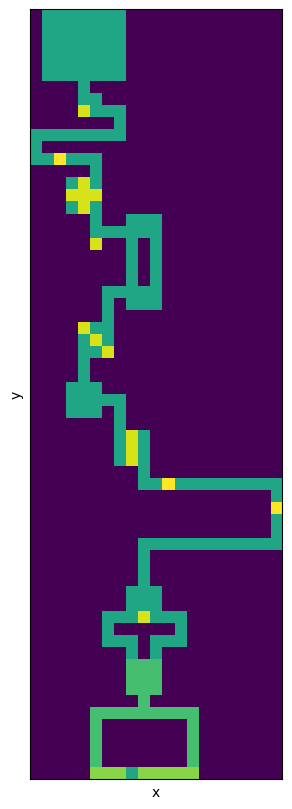

In [129]:
#PREP
local_map_0 = np.zeros((lvl0.x.max()+1,lvl0.y.max()+1)) -10
obstacles = {} # podaje kod z mapy otrzymuje obiekt obsugiwalny typu rock,prop
obj_translator = {
'["r2"]':"prop"
,'["r3"]':"prop"
, '["r1"]':"prop"
, '["g1"]':"prop"
, '["a2"]':"prop"
, '["a1"]':"prop"
, '["e1"]':"prop"
, '["n1"]':"prop"

,'["shrub_variant_1"]' :"grass"
, '["shrub_variant"]' :"grass"
    
,'["stump_variant"]':"rock"
, '["stump_variant_1"]':"rock"
}

xl = lvl0.x.max()
yl = lvl0.y.max()
for __, row in lvl0.iterrows():
    #local_map_0[row.x,row.y] = 0
    match row.state:
        case "wolny":
            local_map_0[row.x,row.y] = 0 #ciemny niebieski
        case "wolny_przygotowany":
            local_map_0[row.x,row.y] = 0  #lekki szary niebieski
        case "niedostepny":
            local_map_0[row.x,row.y] = 2 #
        
        case "zajety_ruchomy":
            obstacles[hash(obj_translator[row.content_type_keys]) % 37] = obj_translator[row.content_type_keys]   
            local_map_0[row.x,row.y] = hash(obj_translator[row.content_type_keys]) % 37  #na mapie jest numerek
        case "zajety_nieruchomy":
            obstacles[hash(obj_translator[row.content_type_keys]) % 37] = obj_translator[row.content_type_keys]   
            local_map_0[row.x,row.y] = hash(obj_translator[row.content_type_keys]) % 37  #na mapie jest numerek
            #local_map_0[row.x,row.y] = 4 #zielonkawy



#start = (8,0)
#local_map_0[start[0],start[1]] = 42


plt.figure(figsize=(10, 10))
plt.imshow(np.rot90(local_map_0))
plt.xticks([])
plt.yticks([])
plt.xlabel("x")
plt.ylabel("y")

plt.show()

In [85]:
obstacles

{4: 'prop', 6: 'rock', 7: 'grass'}

In [79]:
np.unique(local_map_0.astype(int))

array([-10,   0,   2,   4,   6,   7,  42])

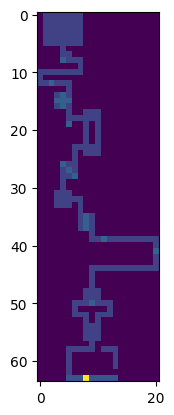

[NEW ANSWER FOUND]
/2 ! 60
!!!
LLLDLUULDRDRRDRUUUULDRUURDRURUUUULUUUULDDDRUURDLUURDLDLLULUU 60


In [139]:
local_map_0_dyn = local_map_0.copy()
local_map_0_dyn = np.where(local_map_0_dyn == 2,0,local_map_0_dyn)

que = deque()

visited = set()

#target = (4,55)
start = (8,0) # 8,0
target = (4,58)
t = 10**7
ans = []
local_map_0_dyn[start[0],start[1]] = 42
local_map_0_dyn[13,1] = -10
local_map_0_dyn[10,5] = -10

plt.imshow(np.rot90(local_map_0_dyn))
plt.show()

que.append((start[0],start[1],0,[],local_map_0_dyn)) #x,y,num,step_list,map

while que:
    #print("--[LICZBA ELEMENTÓW]--",len(que))
    q = que.popleft() #BFS
    #q = que.pop() #DFS wymaga innego visited
    
    if (t < q[2]):
        #print("/1")
        continue
    
    if (q[0],q[1]) == target: #mamy odpowiedź
        print("[NEW ANSWER FOUND]")
        ans.append(q[3])
        t = q[2]
        print("/2","!",q[2])
        continue
    #-------------------------------------------
    #print(q[0],q[1])
    #(X,Y) grid
    for dirc in [(-1,0,"L"),(0,1,"U"),(0,-1,"D"),(1,0,"R")]:
        #print("[KIERUNEK]",dirc[2])
        z = 0 if dirc[1] == 0 else 1 #0 oznacz suwanie gory dół
        new_map,ng = shift_segment(q[4], z, q[1-z],q[z], dirc[0], dirc[1]) #mapa,tryb,pos,row,col
        h = new_map.tobytes()

        if h in visited:
            continue

        if np.array_equal(q[4], new_map):
            continue

        visited.add(h)

        #print("+[MAPA UNIKALNA]+",q[0]+dirc[0],q[1]+dirc[1],f"{q[2]}/{t}")
        que.append((ng[0],ng[1],q[2]+1,q[3]+[dirc[2]],new_map))

        
        #new_map[4,58] = 70
        
        #plt.figure(figsize=(10, 10))
        #plt.imshow(new_map)
        #plt.xticks([])
        #plt.yticks([])
        #plt.xlabel("x")
        #plt.ylabel("y")
        #plt.show()

                
print("!!!")
p = "".join(ans[0])
#print(ans)
print(p,len(p))

In [ ]:
#WORKING WITHOUT -1 FIX

In [92]:
lvl0.loc[(lvl0.state == "zajety_nieruchomy")].sort_values(["x","y"])

,node_short_id,level,state,x,y,direct_neighbors_all,content_type_names,content_type_keys
224,5347,0.5 Dreams,zajety_nieruchomy,2,51,"[5684, 5006]","[""Shrub Variant (1)""]","[""shrub_variant_1""]"
392,5711,0.5 Dreams,zajety_nieruchomy,5,0,"[4971, 4962]","[""G1""]","[""g1""]"
585,4971,0.5 Dreams,zajety_nieruchomy,6,0,"[5514, 5711]","[""E1""]","[""e1""]"
54,5514,0.5 Dreams,zajety_nieruchomy,7,0,"[5685, 4971]","[""R3""]","[""r3""]"
563,5027,0.5 Dreams,zajety_nieruchomy,9,0,"[5548, 5685]","[""A1""]","[""a1""]"
11,5548,0.5 Dreams,zajety_nieruchomy,10,0,"[5453, 5027]","[""R2""]","[""r2""]"
151,5453,0.5 Dreams,zajety_nieruchomy,11,0,"[5697, 5548]","[""R1""]","[""r1""]"
697,4896,0.5 Dreams,zajety_nieruchomy,11,24,"[5429, 5483]","[""Shrub Variant""]","[""shrub_variant""]"
439,5697,0.5 Dreams,zajety_nieruchomy,12,0,"[5072, 5453]","[""A2""]","[""a2""]"
1052,5072,0.5 Dreams,zajety_nieruchomy,13,0,"[5697, 5775]","[""N1""]","[""n1""]"


In [93]:
lvl0.loc[(lvl0.state == "zajety_ruchomy")].sort_values(["x","y"])

,node_short_id,level,state,x,y,direct_neighbors_all,content_type_names,content_type_keys
1046,5044,0.5 Dreams,zajety_ruchomy,3,48,"[5823, 5319, 5589]","[""Stump Variant""]","[""stump_variant""]"
99,5507,0.5 Dreams,zajety_ruchomy,4,37,"[5739, 5318]","[""Stump Variant""]","[""stump_variant""]"
1036,5055,0.5 Dreams,zajety_ruchomy,4,47,"[5635, 5589, 5823]","[""Stump Variant""]","[""stump_variant""]"
288,5823,0.5 Dreams,zajety_ruchomy,4,48,"[5681, 5044, 5696, 5055]","[""Stump Variant""]","[""stump_variant""]"
440,5696,0.5 Dreams,zajety_ruchomy,4,49,"[5298, 5319, 5823]","[""Stump Variant""]","[""stump_variant""]"
603,4994,0.5 Dreams,zajety_ruchomy,4,55,"[5614, 5237]","[""Stump Variant""]","[""stump_variant""]"
418,5693,0.5 Dreams,zajety_ruchomy,5,36,"[5388, 5318, 5739, 4885]","[""Stump Variant""]","[""stump_variant""]"
936,5140,0.5 Dreams,zajety_ruchomy,5,44,[5680],"[""Stump Variant""]","[""stump_variant""]"
425,5681,0.5 Dreams,zajety_ruchomy,5,48,"[5823, 5298, 5635]","[""Stump Variant""]","[""stump_variant""]"
410,5733,0.5 Dreams,zajety_ruchomy,6,35,"[4885, 5388]","[""Stump Variant (1)""]","[""stump_variant_1""]"


In [4]:
#lvl0[lvl0.state=="niedostepny"]

In [94]:
lvl0.loc[(lvl0.y == 55) & (lvl0.x == 4)]

#start = (8,0) #x,y

,node_short_id,level,state,x,y,direct_neighbors_all,content_type_names,content_type_keys
603,4994,0.5 Dreams,zajety_ruchomy,4,55,"[5614, 5237]","[""Stump Variant""]","[""stump_variant""]"


In [73]:
#local_map_0[8,0] #(x,y) grid

0.0

In [76]:
#df.columns

In [24]:
lvl0[lvl0.content_type_keys != "[]"]

,node_short_id,level,state,x,y,direct_neighbors_all,content_type_names,content_type_keys
11,5548,0.5 Dreams,zajety_nieruchomy,10,0,"[5453, 5027]","[""R2""]","[""r2""]"
54,5514,0.5 Dreams,zajety_nieruchomy,7,0,"[5685, 4971]","[""R3""]","[""r3""]"
99,5507,0.5 Dreams,zajety_ruchomy,4,37,"[5739, 5318]","[""Stump Variant""]","[""stump_variant""]"
151,5453,0.5 Dreams,zajety_nieruchomy,11,0,"[5697, 5548]","[""R1""]","[""r1""]"
224,5347,0.5 Dreams,zajety_nieruchomy,2,51,"[5684, 5006]","[""Shrub Variant (1)""]","[""shrub_variant_1""]"
252,5311,0.5 Dreams,zajety_ruchomy,8,27,"[4910, 5160, 5190, 5268]","[""Stump Variant""]","[""stump_variant""]"
288,5823,0.5 Dreams,zajety_ruchomy,4,48,"[5681, 5044, 5696, 5055]","[""Stump Variant""]","[""stump_variant""]"
392,5711,0.5 Dreams,zajety_nieruchomy,5,0,"[4971, 4962]","[""G1""]","[""g1""]"
410,5733,0.5 Dreams,zajety_ruchomy,6,35,"[4885, 5388]","[""Stump Variant (1)""]","[""stump_variant_1""]"
418,5693,0.5 Dreams,zajety_ruchomy,5,36,"[5388, 5318, 5739, 4885]","[""Stump Variant""]","[""stump_variant""]"


In [8]:
lvl0.state.value_counts()

wolny                 128
wolny_przygotowany     48
niedostepny            27
zajety_ruchomy         14
zajety_nieruchomy      11
Name: state, dtype: int64

In [ ]:
mobj = defaultdict(list)

for _,row in lvl0.loc[lvl0.content_type_names != "[]",["x","y","content_type_keys"]].iterrows():
    mobj[row.]
    print(row)

In [196]:
lvl0.columns

Index(['node_short_id', 'level', 'state', 'x', 'y', 'direct_neighbors_all'], dtype='object')

In [149]:
df2  = pd.read_csv("all_levels_slots.csv")

In [147]:
df[valid_col].shape

(1067, 8)

In [ ]:
['node_short_id', 'level','state',"x","y"
             ,"direct_neighbors_all"
             ,"content_type_names","content_type_keys"]

In [152]:
df2.columns,df.columns

(Index(['slot_id', 'transform_id', 'name', 'x', 'y', 'z', 'parent_transform',
        'slot_component', 'flags', 'manual_link', 'links', 'file'],
       dtype='object'),
 Index(['node_id', 'node_short_id', 'level', 'unity_file', 'unity_name',
        'state', 'is_occupied', 'is_unavailable', 'has_staged_content', 'x',
        'y', 'z', 'world_x', 'world_y', 'world_z', 'parent_transform',
        'slot_component', 'is_raft_slot', 'force_hidden', 'completely_hidden',
        'disable_connection', 'content_count', 'movable_content_count',
        'static_content_count', 'staged_content_count', 'occupant_id',
        'hidden_occupant_id', 'content_ids', 'content_type_names',
        'content_type_keys', 'movable_content_ids',
        'movable_content_type_names', 'movable_content_type_keys',
        'static_content_ids', 'static_content_type_names',
        'static_content_type_keys', 'staged_content_ids',
        'staged_content_type_names', 'staged_content_type_keys',
        'staged_mov

In [150]:
df2[valid_col].shape

KeyError: "['node_short_id', 'level', 'state', 'direct_neighbors_all', 'content_type_names', 'content_type_keys'] not in index"

In [31]:
df.iloc[:,0]#.str.split()[1]

0        E:\AssetRipper_win_x64\Export\AssetRipper_expo...
1        E:\AssetRipper_win_x64\Export\AssetRipper_expo...
2        E:\AssetRipper_win_x64\Export\AssetRipper_expo...
3        E:\AssetRipper_win_x64\Export\AssetRipper_expo...
4        E:\AssetRipper_win_x64\Export\AssetRipper_expo...
                               ...                        
17063    E:\AssetRipper_win_x64\Export\AssetRipper_expo...
17064    E:\AssetRipper_win_x64\Export\AssetRipper_expo...
17065    E:\AssetRipper_win_x64\Export\AssetRipper_expo...
17066    E:\AssetRipper_win_x64\Export\AssetRipper_expo...
17067    E:\AssetRipper_win_x64\Export\AssetRipper_expo...
Name: slot_id, Length: 17068, dtype: object

In [ ]:
df.slot_id.transform(lambda x:x.str.split("\\")[-1].split(".unity#")[0])

In [50]:
df.slot_id[0].split("\\")[-1].split(".unity#")[0]

'0.5 Dreams'

In [52]:
s=set()
for l in df.slot_id:
    s.add(l.split("\\")[-1].split(".unity#")[0])

In [53]:
s

{'0.5 Dreams',
 '1 Town1',
 '11 Town5',
 '2 Wild 1',
 '3 Hurveth',
 '4 Wild 2',
 '5 Town2',
 '6 Wild 3',
 '8 Town4'}

In [ ]:
from arranger_bfs import build_solver

allowed_ids = lvl0["node_short_id"].astype(str).tolist()
solver = build_solver(
    "dreams_types_nodes.csv",
    level="0.5 Dreams",
    allowed_ids=allowed_ids,
)

result = solver.solve_xy((7, 63), (5, 5),max_states=20000)
#space=world
#result = solver.solve(start_id="5562", goal_id="5290", max_states=200000)

print(result["moves"])
print(result["states"][:5])

In [6]:
lvl0.loc[(lvl0.x == 7) & (lvl0.y == 63)]

,node_short_id,level,state,x,y,direct_neighbors_all,content_type_names,content_type_keys
161,5402,0.5 Dreams,wolny,7,63,"[5756, 4944]",[],[]
